# Layer 8: Executive Visualization Dashboard

**Objective:** Provide a professional, high-clarity synthesis of market price dispersion and competitive positioning.

**Sections:**
1. Store x City Price Index (Relative Positioning)
2. High-Volume Category Benchmarking
3. Market Price Volatility (Top Branded Categories)
4. Leader Dominance Index (LDI) Comparison

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Premium Global Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   20,
    'axes.labelsize':   14,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})

sns.set_theme(style='whitegrid', font_scale=1.2)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}

BASE_DIR    = Path(os.getcwd()).parent
DATA_DIR    = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load matched data
df = pd.read_csv(DATA_DIR / 'matched' / 'matched_products.csv', low_memory=False)
print(f'Dashboard Ready. Analyzing {len(df):,} price points.')
# --- Premium Global Styling ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)


Dashboard Ready. Analyzing 11,561 price points.


## 8.1 — Store x City Relative Price Matrix
Indices are calculated relative to the average price of the same category in the same city. 
*(1.00 = Market Average | < 1.00 = Cheaper | > 1.00 = Premium)*

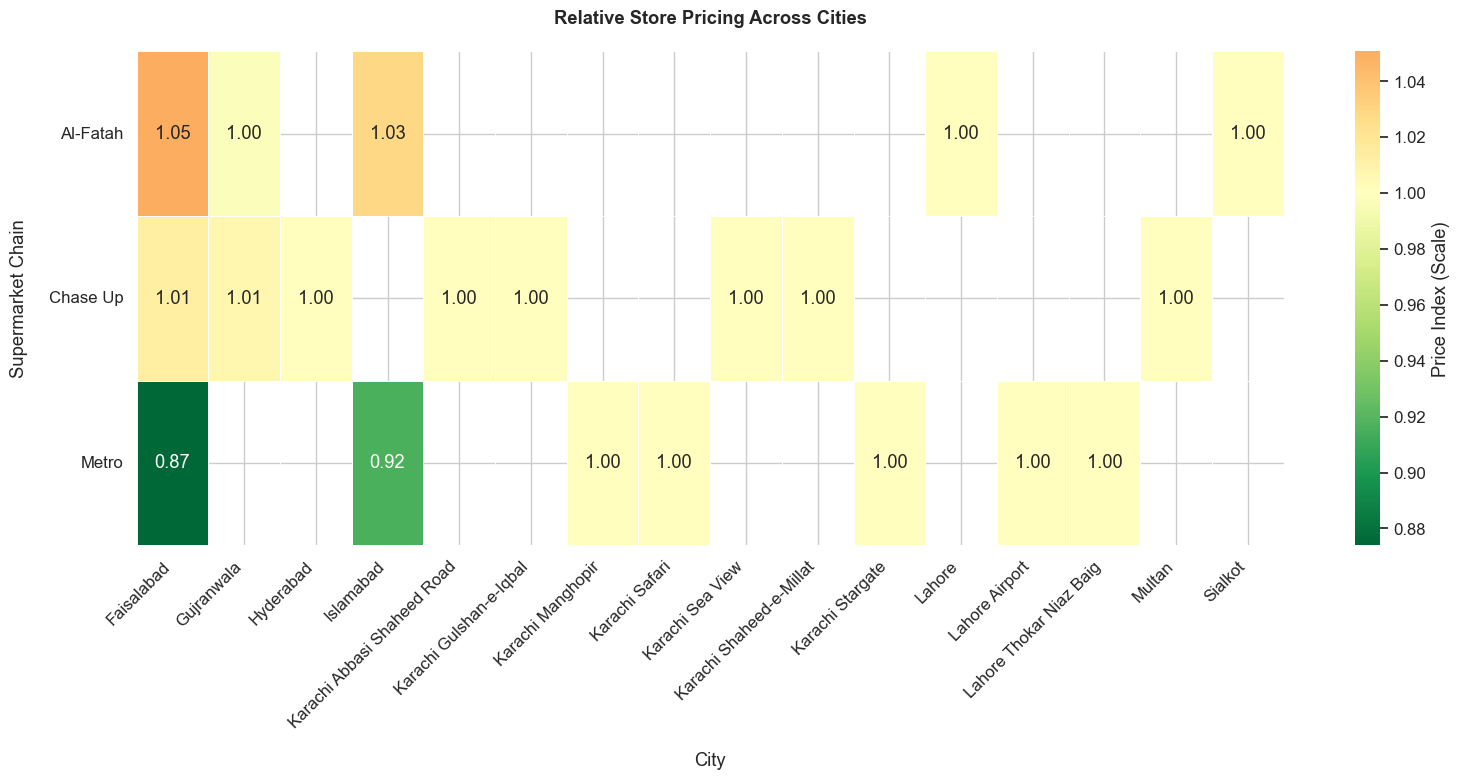

In [2]:
# Calculate Price Position Index
df['category_city_avg'] = df.groupby(['category_normalized', 'city'])['price_clean'].transform('mean')
df['price_index'] = df['price_clean'] / df['category_city_avg']

index_matrix = df.pivot_table(
    index='store_name', 
    columns='city', 
    values='price_index', 
    aggfunc='mean'
)

plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    index_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="RdYlGn_r", 
    center=1.0, 
    linewidths=0.5,
    cbar_kws={'label': 'Price Index (Scale)'}
)

plt.title("Relative Store Pricing Across Cities", pad=20)
plt.xlabel("City", labelpad=15)
plt.ylabel("Supermarket Chain", labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_store_city_matrix.png', dpi=300)
plt.show()

## 8.2 — Category Benchmarking (Top 15 Categories)
Comparison of average prices for the most frequently matched product categories.

<Figure size 1400x1000 with 0 Axes>

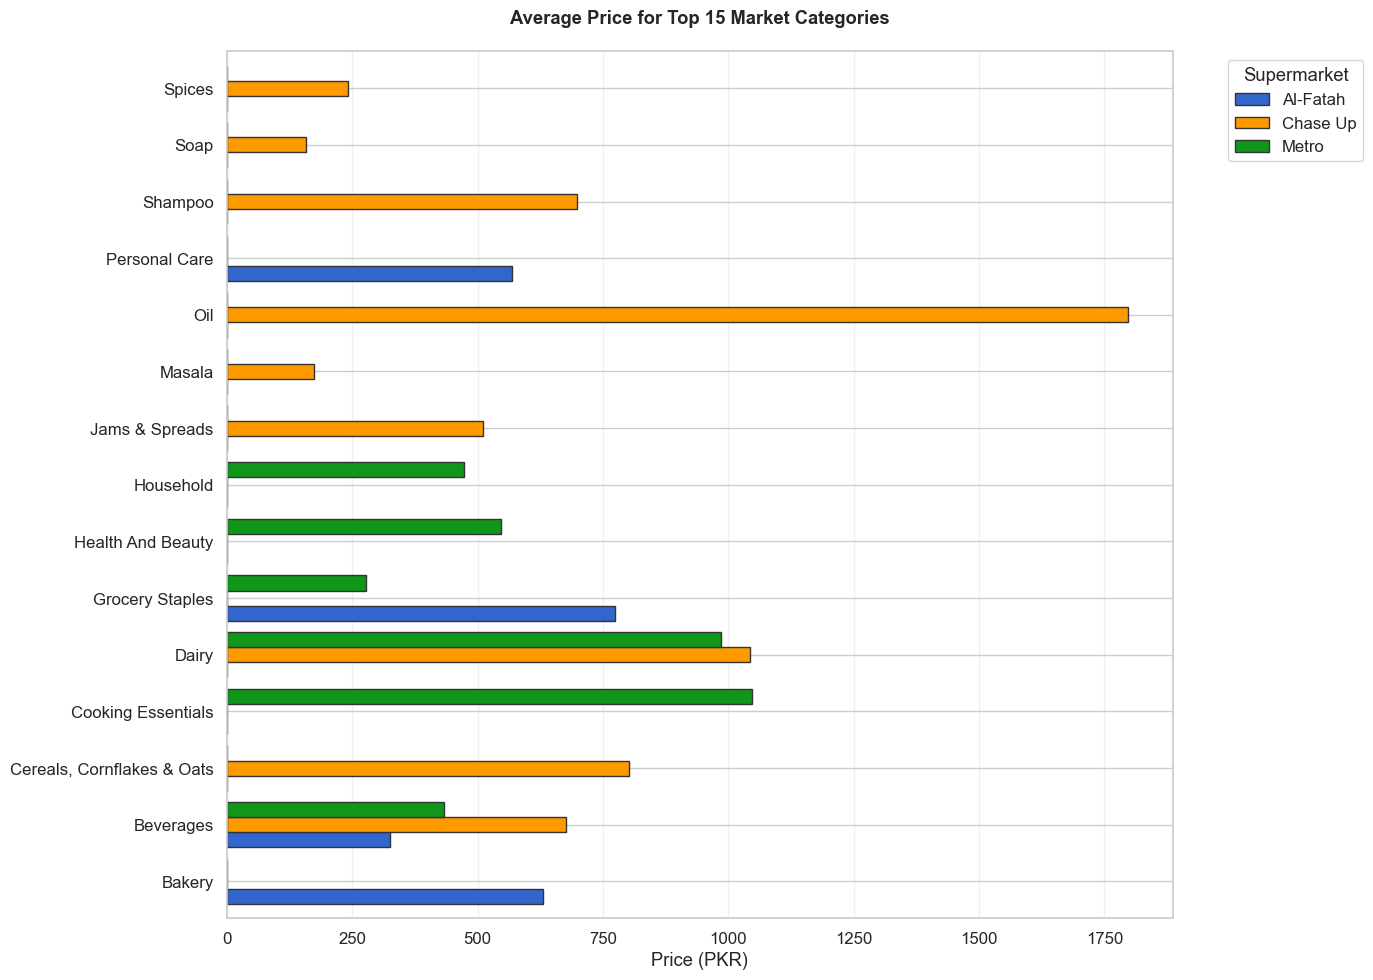

In [3]:
# Filter for Top 15 categories by volume to avoid layout clutter
top_cats = df['category_normalized'].value_counts().nlargest(15).index
df_top = df[df['category_normalized'].isin(top_cats)]

cat_summary = df_top.groupby(['category_normalized', 'store_name'])['price_clean'].mean().unstack()

plt.figure(figsize=(14, 10))
cat_summary.plot(
    kind='barh', 
    figsize=(14, 10), 
    color=[STORE_COLORS.get(x) for x in cat_summary.columns], 
    edgecolor='#333', 
    width=0.8
)

plt.title("Average Price for Top 15 Market Categories", pad=20)
plt.xlabel("Price (PKR)")
plt.ylabel("")
plt.legend(title="Supermarket", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_category_benchmark.png', dpi=300)
plt.show()

## 8.3 — Price Volatility Scoring
Identifying categories with the highest internal price variation across different stores.

C:\Users\Nouman\AppData\Local\Temp\ipykernel_2476\3987577067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


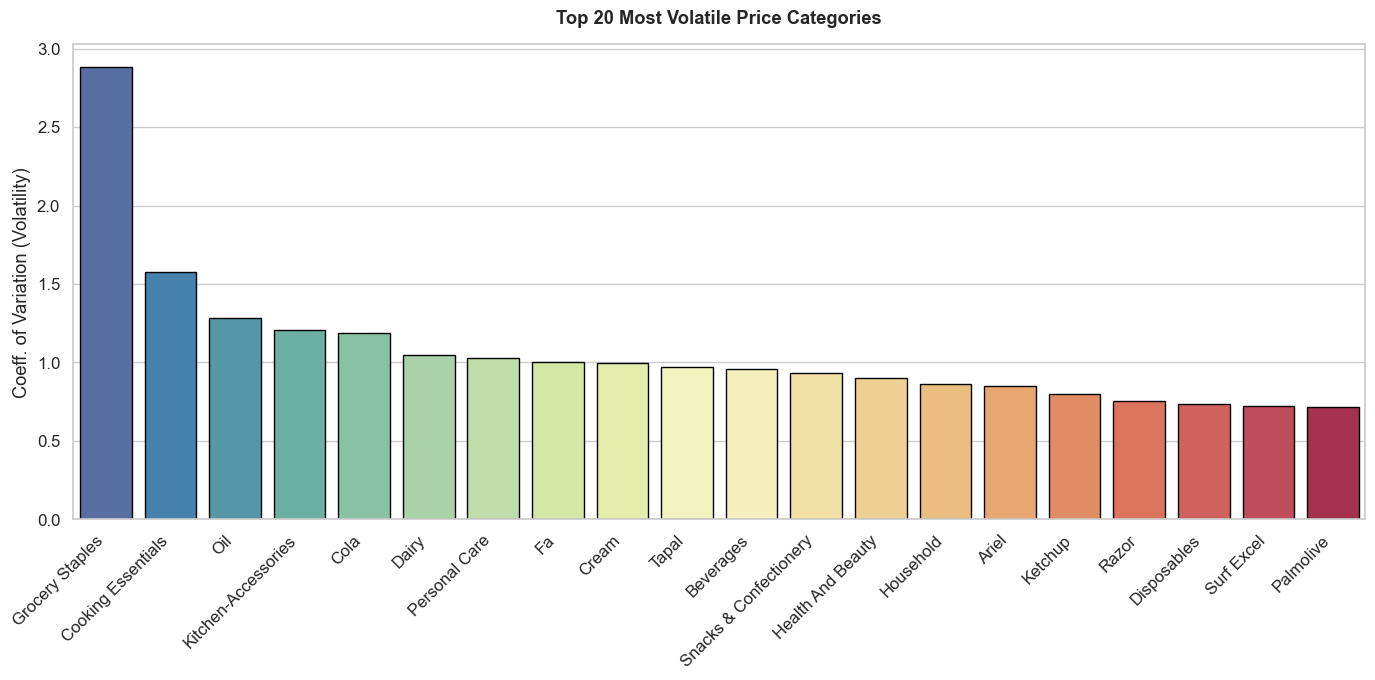

In [4]:
volatility = df.groupby('category_normalized')['price_clean'].std() / df.groupby('category_normalized')['price_clean'].mean()
volatility = volatility.sort_values(ascending=False).head(20).to_frame(name='CV')

plt.figure(figsize=(14, 7))
sns.barplot(
    x=volatility.index, 
    y=volatility['CV'], 
    palette='Spectral_r', 
    edgecolor='black'
)

plt.title("Top 20 Most Volatile Price Categories", pad=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Coeff. of Variation (Volatility)")
plt.xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_category_volatility.png', dpi=300)
plt.show()

## 8.4 — Leader Dominance Index (LDI)
Percentage of times each store offers the lowest price in a matched pair.

C:\Users\Nouman\AppData\Local\Temp\ipykernel_2476\909555394.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


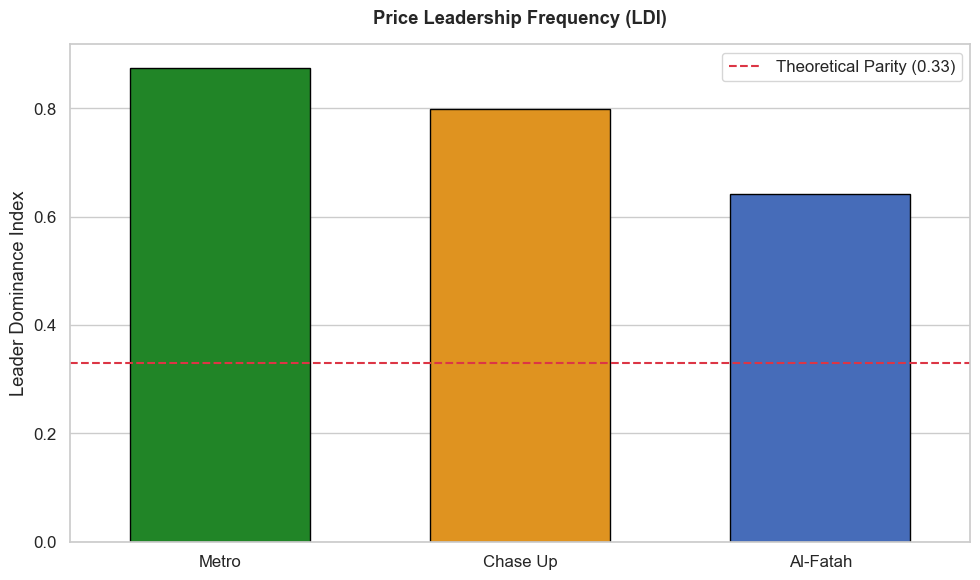

In [5]:
min_prices = df.groupby(['product_id', 'city'])['price_clean'].transform('min')
df['is_lowest'] = df['price_clean'] == min_prices

ldi_scores = df.groupby('store_name')['is_lowest'].mean().sort_values(ascending=False).to_frame(name='LDI')

plt.figure(figsize=(10, 6))
sns.barplot(
    x=ldi_scores.index, 
    y=ldi_scores['LDI'], 
    palette=[STORE_COLORS.get(x) for x in ldi_scores.index], 
    edgecolor='black',
    width=0.6
)

plt.axhline(0.33, color='#dc3545', linestyle='--', label='Theoretical Parity (0.33)')
plt.title("Price Leadership Frequency (LDI)", pad=15)
plt.ylabel("Leader Dominance Index")
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_ldi_comparison.png', dpi=300)
plt.show()